# Setup

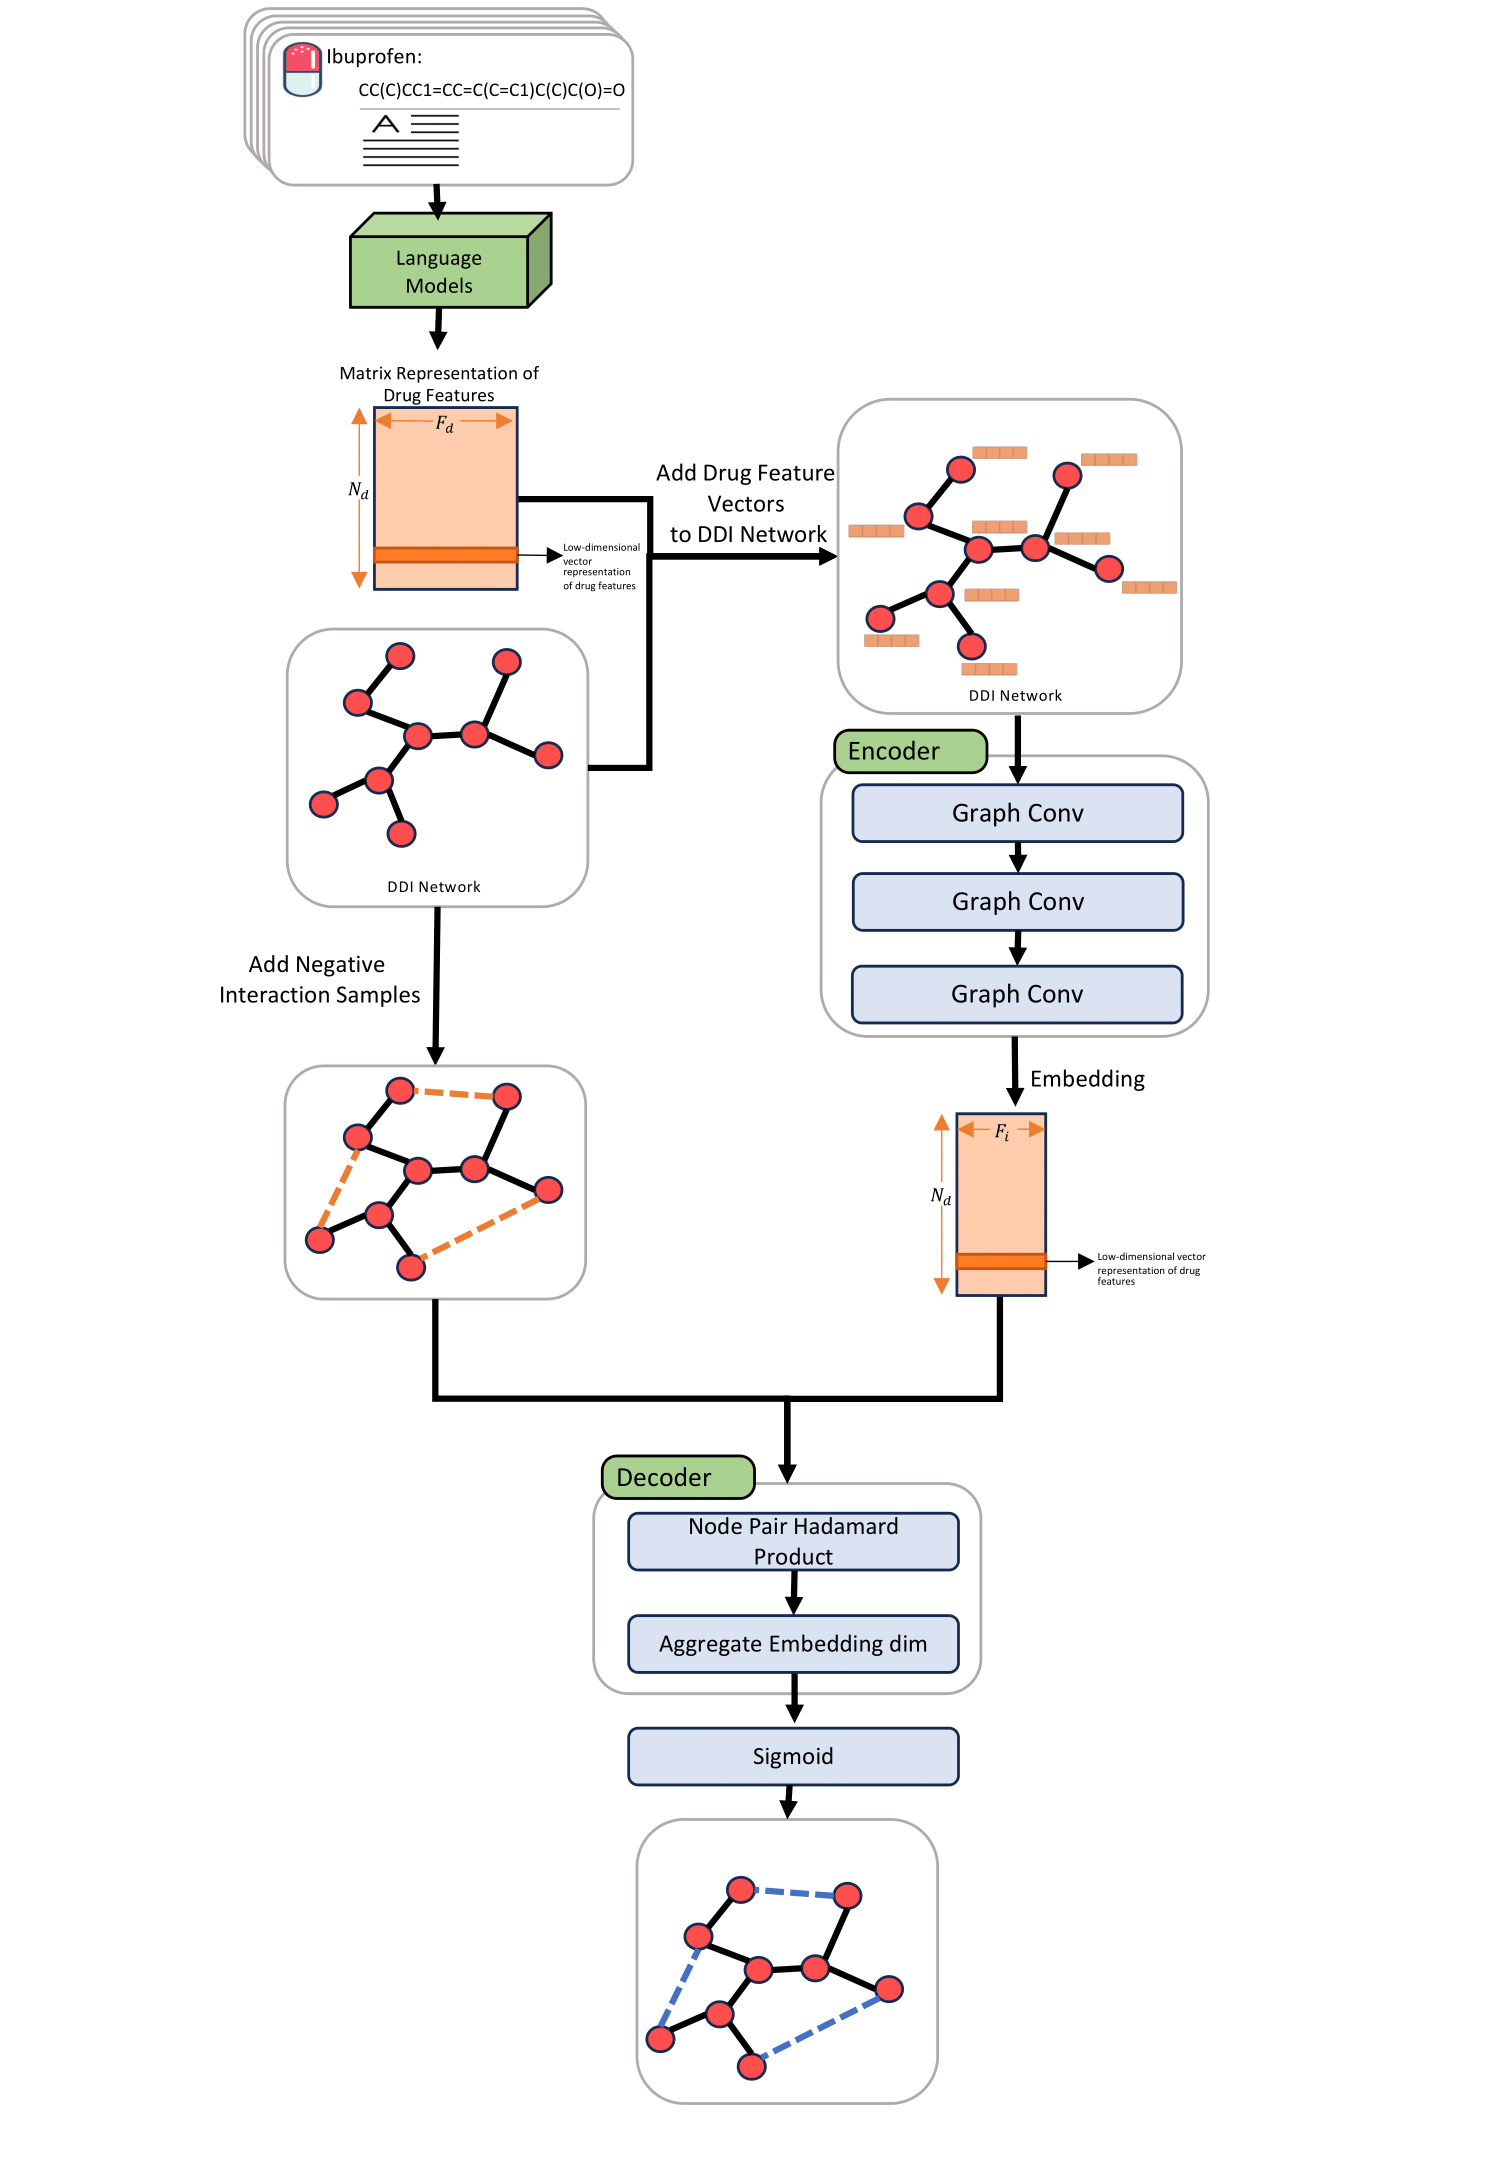

# Experiments

In [1]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
)

import plotly.express as px

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType


warnings.simplefilter(action="ignore", category=FutureWarning)

## Experiments on Loss

In [ ]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.training.repetitions = 1

## Optimizing individual losses

In [ ]:
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.upsample_negative_labels = True # todo: check upsample_negative_labels whether it still works

In [41]:
config.run.pos_loss_multiplier = 0.5

In [42]:
run = main(config)

2026-03-23 12:49:15,654 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-03-23 12:49:18,324 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-03-23 12:49:18,390 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-03-23 12:49:18,392 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-03-23 12:49:18,413 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-03-23 12:49:27,199 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


In [ ]:
settings = [
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
},
{
    "loss_type": LossType.FocalLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "focal_loss_gamma": 2.0  # Reduce the relative loss for well-classified examples. 0.0 is equivalent to WeightedBCEWithLogitsLoss
}
]

In [ ]:
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.run.upsample_negative_labels = True

run = main(config)
logging.getLogger().setLevel(logging.WARNING)

run['metrics']

2026-03-23 10:50:37,589 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-03-23 10:50:40,234 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-03-23 10:50:40,300 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-03-23 10:50:40,305 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003


======== DESC_GPT ========


2026-03-23 10:50:40,533 - DEBUG - Upsampling negative samples by 27794 to balance labels.
2026-03-23 10:50:40,536 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.
2026-03-23 10:50:40,545 - DEBUG - Using imbalanced loss with pos_weight: 0.5000
2026-03-23 10:50:47,145 - DEBUG - Early stopping at epoch 24


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7552
PR_AUC: 0.9734


{'AUC_mean': 0.7552353021617566,
 'AUC_std': 0.0,
 'PR_AUC_mean': 0.9734133146174572,
 'PR_AUC_std': 0.0,
 'repetitions': 1}

In [25]:
run["metrics"]

{'AUC_mean': 0.7552353021617566,
 'AUC_std': 0.0,
 'PR_AUC_mean': 0.9734133146174572,
 'PR_AUC_std': 0.0,
 'repetitions': 1}

## Experiments on Datasets

In [ ]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()


config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.training.repetitions = 1



In [17]:
run = main(config)
logging.getLogger().setLevel(logging.WARNING)

run['metrics']

2026-03-23 10:42:56,000 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-03-23 10:42:58,637 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-03-23 10:42:58,718 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-03-23 10:42:58,723 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-03-23 10:42:58,742 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-03-23 10:43:04,957 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


{'AUC_mean': 0.7824463467987068,
 'AUC_std': 0.0,
 'PR_AUC_mean': 0.9764446332183095,
 'PR_AUC_std': 0.0,
 'repetitions': 1}

# Experiment of Embeddings